<a href="https://colab.research.google.com/github/sathana495/ML_algorithms/blob/main/Advertising_Sales_Prediction1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sales=pd.read_csv('/content/advertising_sales_dataset.csv')
sales

,tv_spend_k_usd,radio_spend_k_usd,newspaper_spend_k_usd,social_media_spend_k_usd,sales_units_thousand
0,14.62,48.77,2.91,78.52,22.29
1,86.73,32.24,40.17,73.68,23.17
2,216.29,15.99,81.19,42.94,24.36
3,6.48,39.52,21.83,57.04,13.63
4,61.78,0.88,20.35,57.76,13.63
...,...,...,...,...,...
495,276.66,2.08,96.29,57.41,27.38
496,245.89,25.29,41.10,60.12,29.43
497,52.96,44.77,17.89,25.55,13.89
498,176.32,37.02,59.97,5.08,26.70


In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tv_spend_k_usd            500 non-null    float64
 1   radio_spend_k_usd         500 non-null    float64
 2   newspaper_spend_k_usd     500 non-null    float64
 3   social_media_spend_k_usd  500 non-null    float64
 4   sales_units_thousand      500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


In [12]:
sales.describe()

,tv_spend_k_usd,radio_spend_k_usd,newspaper_spend_k_usd,social_media_spend_k_usd,sales_units_thousand
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,154.476660,24.435340,49.584480,39.440300,20.598900
std,87.175982,14.616531,28.474807,23.322043,6.009243
min,0.310000,0.130000,0.350000,0.060000,3.120000
25%,81.170000,12.030000,23.725000,19.315000,16.307500
50%,154.665000,23.495000,50.405000,39.230000,20.910000
75%,232.740000,36.392500,73.277500,60.122500,25.055000
max,298.590000,49.950000,99.910000,79.980000,37.160000


In [13]:
sales.isnull().sum()

,0
tv_spend_k_usd,0
radio_spend_k_usd,0
newspaper_spend_k_usd,0
social_media_spend_k_usd,0
sales_units_thousand,0


In [14]:
sales.columns

Index(['tv_spend_k_usd', 'radio_spend_k_usd', 'newspaper_spend_k_usd',
       'social_media_spend_k_usd', 'sales_units_thousand'],
      dtype='object')

In [15]:
sales.duplicated().sum()

np.int64(0)

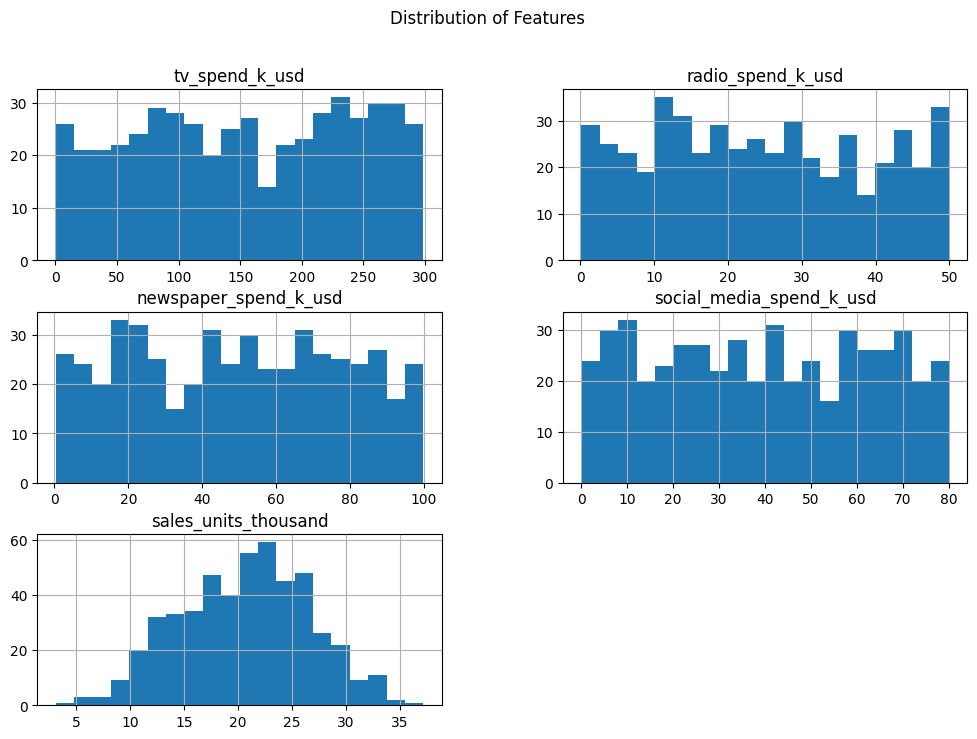

In [16]:
sales.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Features")
plt.show()

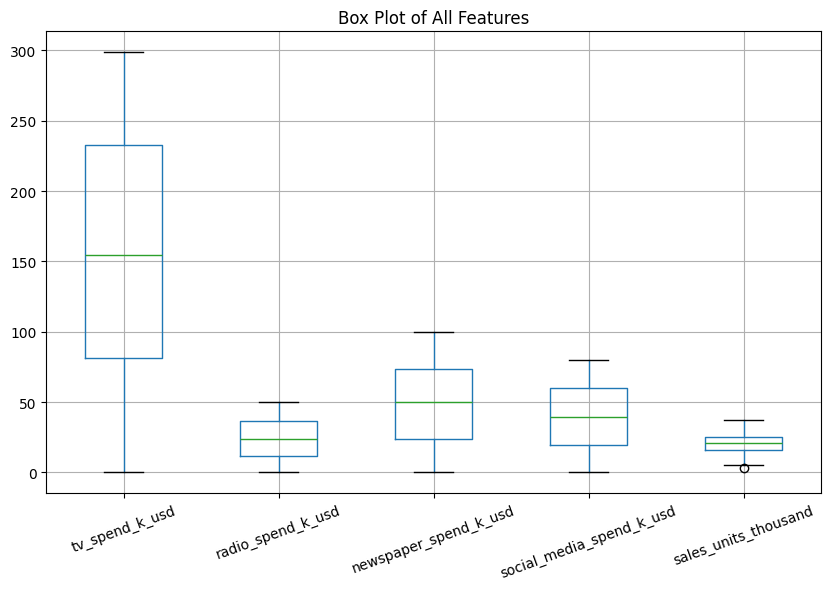

In [17]:
plt.figure(figsize=(10,6))
sales.boxplot()
plt.title("Box Plot of All Features")
plt.xticks(rotation=20)
plt.show()

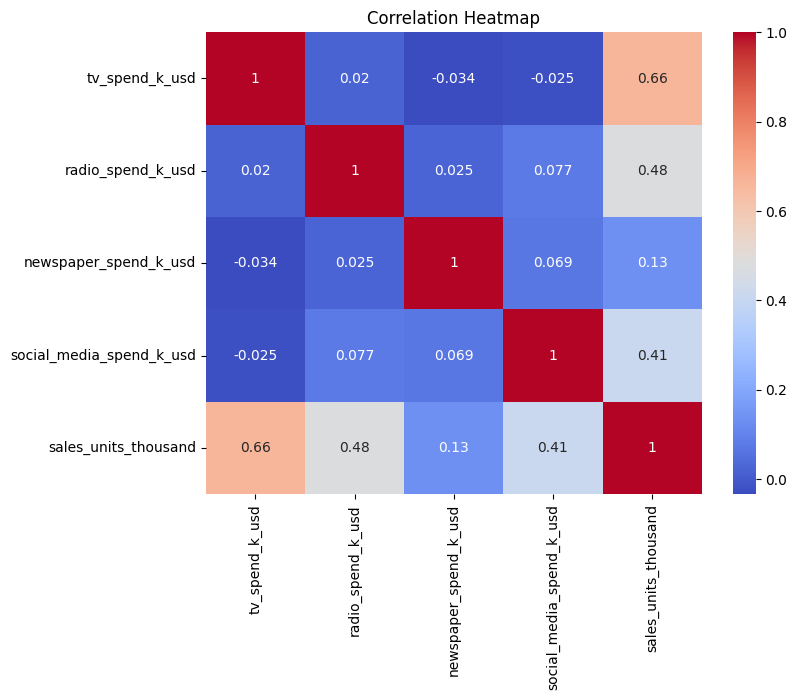

In [18]:

plt.figure(figsize=(8,6))
sns.heatmap(sales.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
X = sales.drop("sales_units_thousand", axis=1)
y = sales["sales_units_thousand"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: 0.8546419446035608


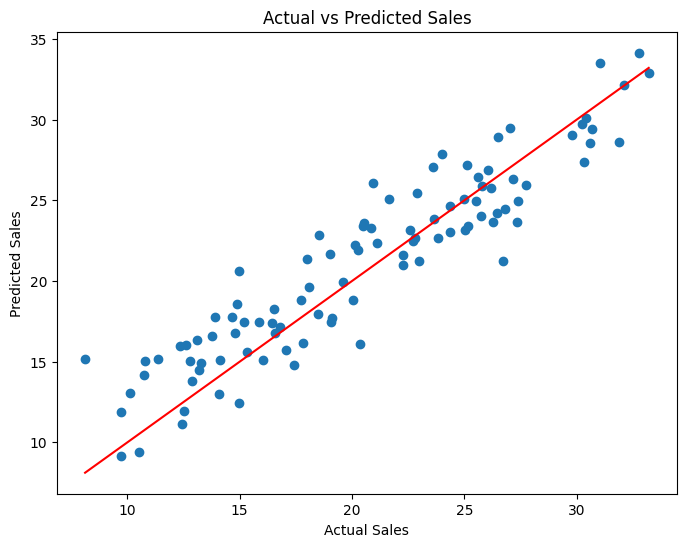

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()